# Clustering Analysis — P1 vs P2

Analisi non supervisionata sugli embedding E5 dei ticket P1 e P2.
Obiettivo: capire se esiste struttura separabile nello spazio degli embedding
indipendentemente dalle label assegnate dagli operatori.

In [1]:
import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_SOURCE = 'sklearn'
except ImportError:
    import hdbscan as hdbscan_lib
    HDBSCAN_SOURCE = 'hdbscan'

import umap

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'HDBSCAN source: {HDBSCAN_SOURCE}')

HDBSCAN source: sklearn


## STEP 1 — Prepara i dati

In [2]:
# notebooks/analysis/ → .parent → notebooks/ → .parent → TicketClassifier/
BASE_DIR  = Path(os.path.abspath('')).parent.parent
CSV_PATH  = BASE_DIR / 'data' / 'dataset_clean.csv'
EMB_TRAIN = BASE_DIR / 'embeddings' / 'e5_train.npy'

SOGLIA_SPLIT = pd.Timestamp('2025-11-01')
RANDOM_STATE = 42

print(f'BASE_DIR : {BASE_DIR}')
print(f'CSV      : {CSV_PATH.exists()}')
print(f'EMB TRAIN: {EMB_TRAIN.exists()}')

BASE_DIR : c:\Users\matteo.segatto\Desktop\TicketClassifier
CSV      : True
EMB TRAIN: True


In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df['data_creazione'] = pd.to_datetime(df['data_creazione'], errors='coerce')

# Split temporale — stesso identico split usato in PriorityClassifier
df_all_train = df[df['data_creazione'] < SOGLIA_SPLIT].copy()

print(f'Dataset totale   : {len(df):,} righe')
print(f'Train (< {SOGLIA_SPLIT.date()}): {len(df_all_train):,} righe')
print(f'\nDistribuzione priorita_finale (train):')
print(df_all_train['priorita_finale'].value_counts())

Dataset totale   : 61,156 righe
Train (< 2025-11-01): 46,347 righe

Distribuzione priorita_finale (train):
priorita_finale
P3    24973
P2    13650
P1     6501
P4     1223
Name: count, dtype: int64


In [4]:
# Filtra solo P1 e P2
df_p1p2 = df_all_train[df_all_train['priorita_finale'].isin(['P1', 'P2'])].dropna(subset=['priorita_finale']).copy()

print(f'Ticket P1+P2 nel train: {len(df_p1p2):,}')
print(df_p1p2['priorita_finale'].value_counts())

Ticket P1+P2 nel train: 20,151
priorita_finale
P2    13650
P1     6501
Name: count, dtype: int64


In [5]:
# Carica embeddings e allinea con get_indexer (stesso pattern di AreaClassifier/PriorityClassifier)
X_train_full = np.load(EMB_TRAIN)
print(f'Shape embedding train full: {X_train_full.shape}')

idx = df_all_train.index.get_indexer(df_p1p2.index)
assert (idx >= 0).all(), 'get_indexer ha trovato indici non mappati (-1)'

X = X_train_full[idx]            # shape: (n_p1p2, 768)
y = df_p1p2['priorita_finale'].values  # 'P1' o 'P2'

assert X.shape[0] == len(y)
print(f'Shape X allineato: {X.shape}')
print(f'Classi y: {np.unique(y, return_counts=True)}')

Shape embedding train full: (48813, 768)
Shape X allineato: (20151, 768)
Classi y: (array(['P1', 'P2'], dtype=object), array([ 6501, 13650]))


## STEP 2 — Riduzione dimensionalità con UMAP

In [6]:
# UMAP 2d — per visualizzazione
print('Fitting UMAP 2d...')
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE,
    verbose=False
)
X_2d = reducer_2d.fit_transform(X)
print(f'Shape 2d: {X_2d.shape}')

Fitting UMAP 2d...
Shape 2d: (20151, 2)


In [7]:
# UMAP 50d — per clustering (più struttura rispetto al 2d)
print('Fitting UMAP 50d...')
reducer_50d = umap.UMAP(
    n_components=50,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE,
    verbose=False
)
X_50d = reducer_50d.fit_transform(X)
print(f'Shape 50d: {X_50d.shape}')

Fitting UMAP 50d...
Shape 50d: (20151, 50)


## STEP 3 — Clustering: KMeans e HDBSCAN

In [8]:
def cluster_summary(labels_pred, labels_true, X_feat, name):
    """Stampa ARI, silhouette e distribuzione P1/P2 per ogni cluster trovato."""
    mask = labels_pred >= 0  # esclude noise (-1) per HDBSCAN
    n_clusters = len(set(labels_pred[mask]))
    n_noise    = (labels_pred == -1).sum()

    ari  = adjusted_rand_score(labels_true[mask], labels_pred[mask])
    sil  = silhouette_score(X_feat[mask], labels_pred[mask]) if n_clusters > 1 else float('nan')

    print(f'\n=== {name} ===')
    print(f'  N cluster trovati : {n_clusters}')
    if n_noise > 0:
        print(f'  N noise (-1)      : {n_noise} ({n_noise/len(labels_pred):.1%})')
    print(f'  ARI vs P1/P2      : {ari:.4f}')
    print(f'  Silhouette        : {sil:.4f}')

    print('  Distribuzione P1/P2 per cluster:')
    df_tmp = pd.DataFrame({'cluster': labels_pred, 'label': labels_true})
    ct = pd.crosstab(df_tmp['cluster'], df_tmp['label'], normalize='index') * 100
    print(ct.round(1).to_string())

    return {'name': name, 'ari': ari, 'silhouette': sil,
            'n_clusters': n_clusters, 'labels': labels_pred}

In [9]:
# KMeans k = 2, 3, 4, 5
kmeans_results = {}
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_50d)
    res = cluster_summary(labels, y, X_50d, f'KMeans k={k}')
    kmeans_results[k] = res


=== KMeans k=2 ===
  N cluster trovati : 2
  ARI vs P1/P2      : -0.0001
  Silhouette        : 0.2879
  Distribuzione P1/P2 per cluster:
label      P1    P2
cluster            
0        32.2  67.8
1        32.3  67.7

=== KMeans k=3 ===
  N cluster trovati : 3
  ARI vs P1/P2      : -0.0014
  Silhouette        : 0.3056
  Distribuzione P1/P2 per cluster:
label      P1    P2
cluster            
0        32.4  67.6
1        30.8  69.2
2        32.3  67.7

=== KMeans k=4 ===
  N cluster trovati : 4
  ARI vs P1/P2      : -0.0009
  Silhouette        : 0.3473
  Distribuzione P1/P2 per cluster:
label      P1    P2
cluster            
0        32.4  67.6
1        32.4  67.6
2        32.1  67.9
3        31.3  68.7

=== KMeans k=5 ===
  N cluster trovati : 5
  ARI vs P1/P2      : -0.0004
  Silhouette        : 0.3723
  Distribuzione P1/P2 per cluster:
label      P1    P2
cluster            
0        32.3  67.7
1        32.7  67.3
2        32.0  68.0
3        32.3  67.7
4        31.4  68.6


In [10]:
# HDBSCAN min_cluster_size=50
if HDBSCAN_SOURCE == 'sklearn':
    hdb = HDBSCAN(min_cluster_size=50, metric='euclidean')
    hdb_labels = hdb.fit_predict(X_50d)
else:
    hdb = hdbscan_lib.HDBSCAN(min_cluster_size=50, metric='euclidean', prediction_data=True)
    hdb_labels = hdb.fit_predict(X_50d)

hdb_res = cluster_summary(hdb_labels, y, X_50d, 'HDBSCAN min_cluster_size=50')


=== HDBSCAN min_cluster_size=50 ===
  N cluster trovati : 38
  N noise (-1)      : 11514 (57.1%)
  ARI vs P1/P2      : -0.0000
  Silhouette        : 0.4439
  Distribuzione P1/P2 per cluster:
label      P1    P2
cluster            
-1       32.0  68.0
 0       34.6  65.4
 1       31.5  68.5
 2       38.8  61.3
 3       39.8  60.2
 4       34.7  65.3
 5       31.0  69.0
 6       33.0  67.0
 7       33.8  66.2
 8       33.0  67.0
 9       34.1  65.9
 10      30.8  69.2
 11      27.1  72.9
 12      40.6  59.4
 13      30.0  70.0
 14      37.0  63.0
 15      29.8  70.2
 16      30.5  69.5
 17      29.5  70.5
 18      35.8  64.2
 19      35.5  64.5
 20      33.0  67.0
 21      33.5  66.5
 22      34.3  65.7
 23      36.9  63.1
 24      32.6  67.4
 25      37.9  62.1
 26      35.8  64.2
 27      32.3  67.7
 28      36.6  63.4
 29      29.9  70.1
 30      31.6  68.4
 31      26.3  73.7
 32      25.0  75.0
 33      30.6  69.4
 34      29.5  70.5
 35      30.2  69.8
 36      32.7  67.3
 37     

In [11]:
# Tabella riepilogativa
rows = []
for k, r in kmeans_results.items():
    rows.append({'Metodo': r['name'], 'N cluster': r['n_clusters'],
                 'ARI': round(r['ari'], 4), 'Silhouette': round(r['silhouette'], 4)})
rows.append({'Metodo': hdb_res['name'], 'N cluster': hdb_res['n_clusters'],
             'ARI': round(hdb_res['ari'], 4), 'Silhouette': round(hdb_res['silhouette'], 4)})

df_results = pd.DataFrame(rows).set_index('Metodo')
print('\n=== RIEPILOGO METRICHE ===')
display(df_results)


=== RIEPILOGO METRICHE ===


,N cluster,ARI,Silhouette
Metodo,,,
KMeans k=2,2,-0.0001,0.2879
KMeans k=3,3,-0.0014,0.3056
KMeans k=4,4,-0.0009,0.3473
KMeans k=5,5,-0.0004,0.3723
HDBSCAN min_cluster_size=50,38,-0.0000,0.4439


## STEP 4 — Visualizzazioni UMAP 2d

In [12]:
PALETTE_LABEL   = {'P1': '#e74c3c', 'P2': '#3498db'}
PALETTE_CLUSTER = ['#2ecc71', '#e67e22', '#9b59b6', '#1abc9c', '#f39c12']

def scatter_umap(ax, X_2d, color_vals, palette, title, legend_labels=None, alpha=0.35, s=6):
    unique_vals = sorted(set(color_vals))
    for i, val in enumerate(unique_vals):
        mask = np.array(color_vals) == val
        col = palette[val] if isinstance(palette, dict) else palette[i % len(palette)]
        lbl = legend_labels[i] if legend_labels else str(val)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=col, label=lbl,
                   alpha=alpha, s=s, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(markerscale=3, framealpha=0.8)
    ax.set_aspect('equal', 'datalim')

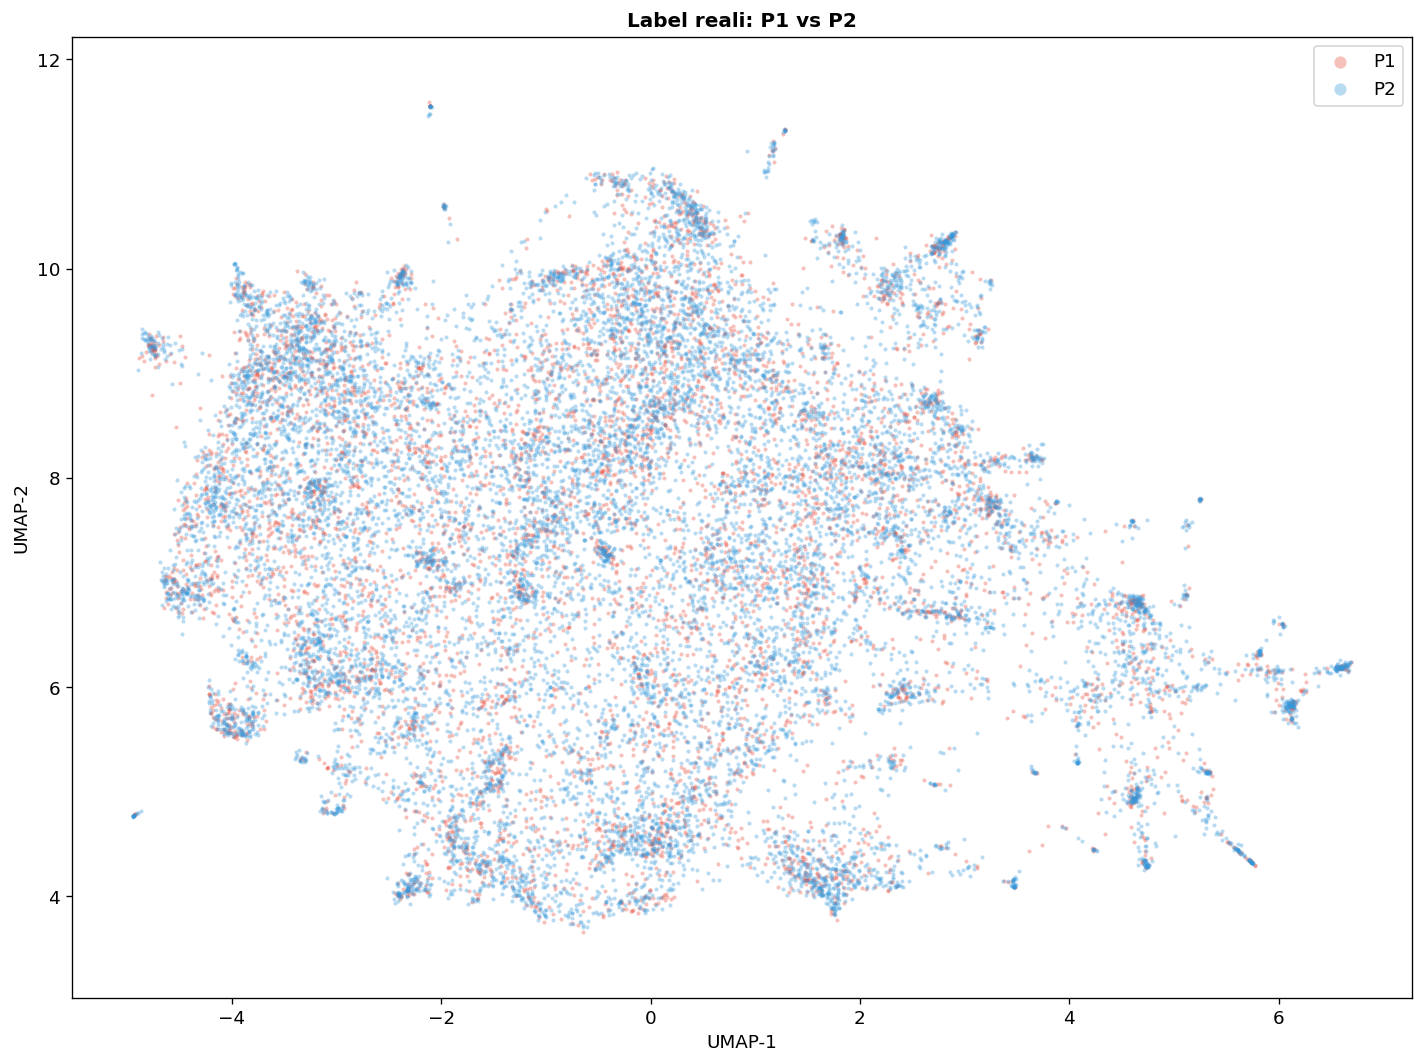

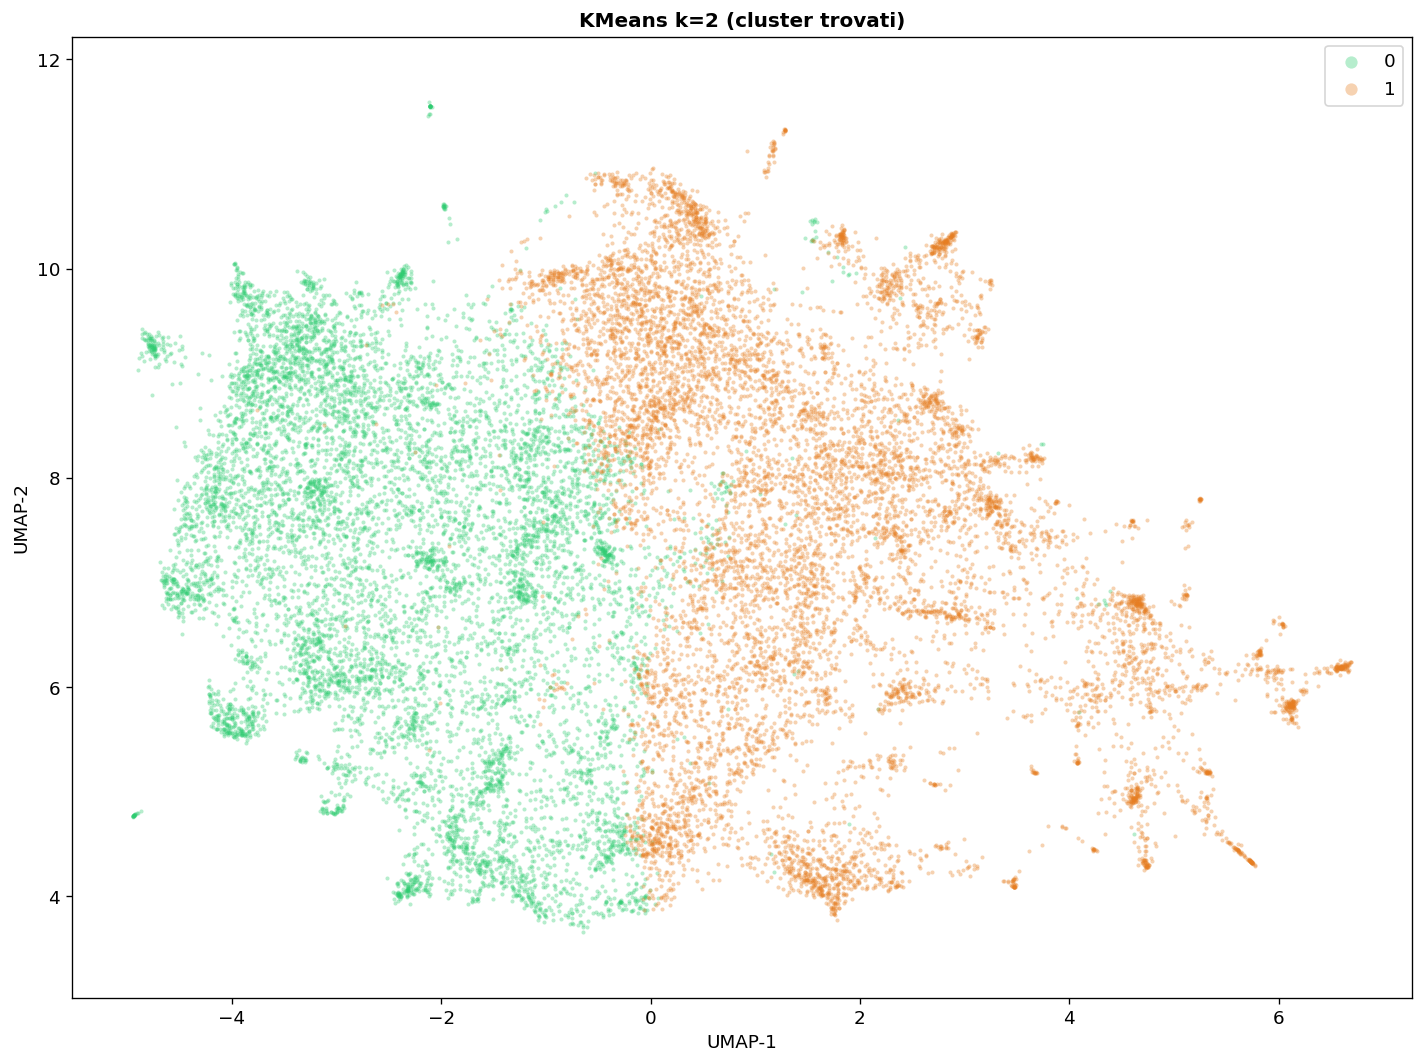

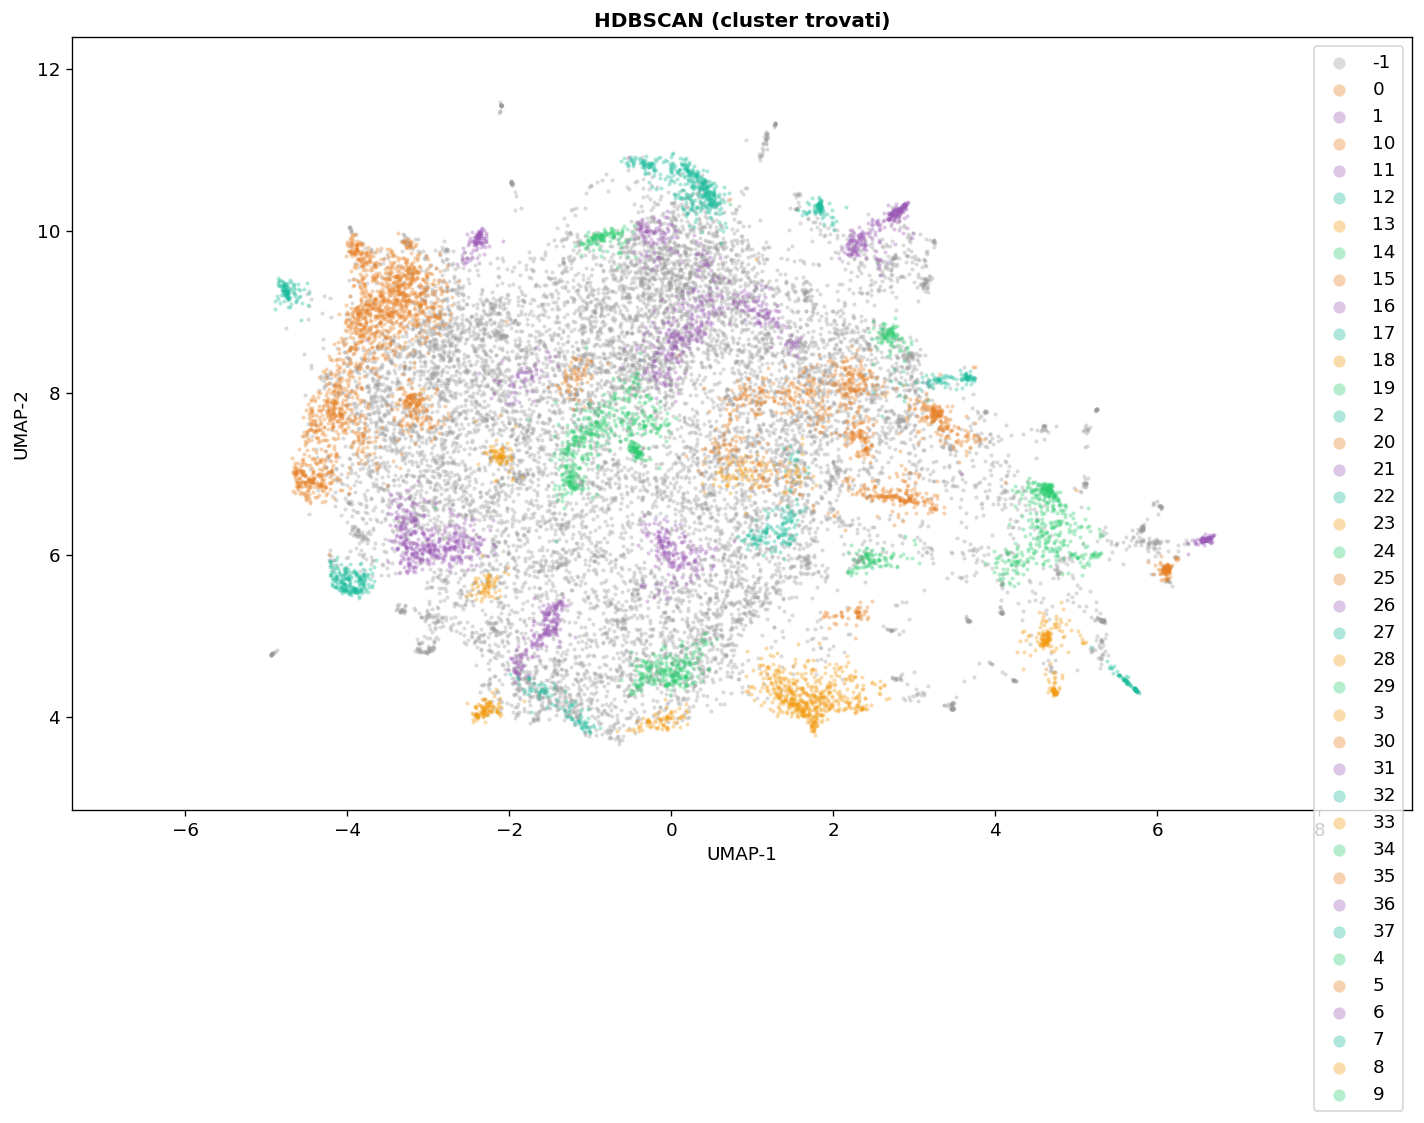

In [ ]:
# Plot 1: Label reali
fig, ax = plt.subplots(figsize=(12, 9))
scatter_umap(ax, X_2d, list(y), PALETTE_LABEL, 'Label reali: P1 vs P2')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'umap_labels.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: KMeans k=2
fig, ax = plt.subplots(figsize=(12, 9))
km2_labels = kmeans_results[2]['labels'].astype(str)
scatter_umap(ax, X_2d, list(km2_labels), PALETTE_CLUSTER, 'KMeans k=2 (cluster trovati)')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'umap_kmeans2.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: HDBSCAN
fig, ax = plt.subplots(figsize=(12, 9))
hdb_plot_labels = hdb_labels.astype(str)
hdb_palette = {str(v): ('#999999' if v == -1 else PALETTE_CLUSTER[i % len(PALETTE_CLUSTER)])
               for i, v in enumerate(sorted(set(hdb_labels)))}
scatter_umap(ax, X_2d, list(hdb_plot_labels), hdb_palette, 'HDBSCAN (cluster trovati)')
plt.tight_layout()
#plt.savefig(BASE_DIR / 'data' / 'umap_hdbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 5 — Analisi qualitativa: top parole per cluster

In [ ]:
import re

# Stopwords italiane minimali — espandibile
STOPWORDS_IT = {
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una', 'di', 'del', 'della',
    'dei', 'degli', 'delle', 'a', 'al', 'alla', 'ai', 'agli', 'alle', 'da', 'dal',
    'dalla', 'dai', 'dagli', 'dalle', 'in', 'nel', 'nella', 'nei', 'negli', 'nelle',
    'su', 'sul', 'sulla', 'sui', 'sugli', 'sulle', 'per', 'tra', 'fra', 'con',
    'e', 'o', 'ma', 'se', 'che', 'chi', 'cui', 'non', 'si', 'mi', 'ti', 'ci',
    'vi', 'ne', 'ho', 'hai', 'ha', 'abbiamo', 'avete', 'hanno', 'è', 'sei', 'siamo',
    'sono', 'era', 'erano', 'sarà', 'essere', 'avere', 'fare', 'questo', 'questa',
    'questi', 'queste', 'quello', 'quella', 'quelli', 'quelle', 'anche', 'come',
    'quando', 'dove', 'perché', 'quindi', 'però', 'allora', 'già', 'ancora',
    'dopo', 'prima', 'sempre', 'mai', 'più', 'meno', 'molto', 'poco', 'tutto',
    'tutti', 'tutte', 'ogni', 'qualche', 'stesso', 'stessa', 'suo', 'sua',
    'suoi', 'sue', 'mio', 'mia', 'miei', 'mie', 'tuo', 'tua', 'nostro', 'nostra',
    'vostro', 'vostra', 'loro', 'cui', 'che', 'query', 'ticket', 'gentile', 'buongiorno',
    'buonasera', 'salve', 'cordiali', 'saluti', 'grazie', 'prego', 'cliente', 'operatore',
    'supporto', 'assistenza', 'ciao', 'buona', 'giornata', 'distinti', 'cordialmente'
}

def tokenize(text):
    """Tokenizzazione semplice: lowercase, solo alfanumerici, min 3 char, no stopwords."""
    if not isinstance(text, str):
        return []
    tokens = re.findall(r'[a-záàâãäèéêëìíîïòóôõöùúûüýÿ]+', text.lower())
    return [t for t in tokens if len(t) >= 3 and t not in STOPWORDS_IT]


def top_words_per_cluster(cluster_labels, df_subset, text_col='testo_input', top_n=10):
    """Restituisce DataFrame con top_n parole per cluster (esclude noise -1)."""
    results = {}
    for cid in sorted(set(cluster_labels)):
        if cid == -1:
            continue
        mask = cluster_labels == cid
        texts = df_subset.loc[mask, text_col].fillna('').tolist()
        all_tokens = []
        for t in texts:
            all_tokens.extend(tokenize(t))
        counter = Counter(all_tokens)
        results[f'Cluster {cid}'] = [w for w, _ in counter.most_common(top_n)]
    return pd.DataFrame(results)

In [ ]:
# Allinea df_p1p2 agli stessi indici usati per X (reset per usare array numpy)
df_p1p2_reset = df_p1p2.reset_index(drop=True)

# ---- KMeans k=2 ----
print('=== Top 10 parole per cluster — KMeans k=2 ===')
km2_top = top_words_per_cluster(kmeans_results[2]['labels'], df_p1p2_reset, top_n=10)
display(km2_top)

print('\nDistribuzione P1/P2 nei cluster KMeans k=2:')
df_km2_dist = pd.DataFrame({'cluster': kmeans_results[2]['labels'], 'label': y})
display(pd.crosstab(df_km2_dist['cluster'], df_km2_dist['label']))

=== Top 10 parole per cluster — KMeans k=2 ===


,Cluster 0,Cluster 1
0,errore,errore
1,programma,fatture
2,fatture,problema
3,problema,programma
4,fattura,dell
5,dell,fattura
6,aggiornamento,data
7,chiedo,chiedo
8,dati,quanto
9,quanto,dati



Distribuzione P1/P2 nei cluster KMeans k=2:


label,P1,P2
cluster,,
0,3082,6478
1,3419,7172


In [ ]:
# ---- KMeans k=3 ----
print('=== Top 10 parole per cluster — KMeans k=3 ===')
km3_top = top_words_per_cluster(kmeans_results[3]['labels'], df_p1p2_reset, top_n=10)
display(km3_top)

print('\nDistribuzione P1/P2 nei cluster KMeans k=3:')
df_km3_dist = pd.DataFrame({'cluster': kmeans_results[3]['labels'], 'label': y})
display(pd.crosstab(df_km3_dist['cluster'], df_km3_dist['label']))

=== Top 10 parole per cluster — KMeans k=3 ===


,Cluster 0,Cluster 1,Cluster 2
0,errore,errore,errore
1,programma,fatture,programma
2,fatture,programma,fatture
3,dell,problema,problema
4,problema,chiedo,fattura
5,fattura,dati,aggiornamento
6,data,aggiornamento,chiedo
7,chiedo,quanto,dell
8,dati,fattura,dati
9,quanto,riscontro,quanto



Distribuzione P1/P2 nei cluster KMeans k=3:


label,P1,P2
cluster,,
0,3472,7234
1,500,1121
2,2529,5295


In [ ]:
# ---- HDBSCAN ----
print('=== Top 10 parole per cluster — HDBSCAN ===')
hdb_top = top_words_per_cluster(hdb_labels, df_p1p2_reset, top_n=10)
display(hdb_top)

print('\nDistribuzione P1/P2 nei cluster HDBSCAN (incluso noise -1):')
df_hdb_dist = pd.DataFrame({'cluster': hdb_labels, 'label': y})
display(pd.crosstab(df_hdb_dist['cluster'], df_hdb_dist['label']))

=== Top 10 parole per cluster — HDBSCAN ===


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,...,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32,Cluster 33,Cluster 34,Cluster 35,Cluster 36,Cluster 37
0,errore,errore,errore,errore,dell,errore,errore,mese,errore,errore,...,errore,errore,errore,errore,problema,errore,errore,errore,errore,errore
1,fatture,problema,riscontro,data,errore,programma,problema,errore,aggiornamento,chiedo,...,programma,fatture,fatture,mese,fattura,fattura,fatture,fatture,programma,fatture
2,presente,data,dati,flusso,dipendente,cartella,cartella,dipendente,fattura,problema,...,dipendente,quanto,problema,fatture,quanto,programma,problema,programma,fatture,problema
3,ore,fatture,programma,problema,attesa,chiedo,all,buon,problema,fattura,...,riscontro,stampa,programma,fattura,programma,problema,programma,nuova,dipendente,programma
4,quanto,programma,aggiornamento,file,fatture,fattura,fatture,problema,riscontro,programma,...,problema,programma,fattura,ospiti,errore,dipendente,aggiornamento,sosia,quanto,fattura
5,ora,dell,file,all,quanto,presenze,programma,devo,dati,file,...,attesa,dell,aggiornamento,presenze,riesco,data,ore,attesa,problema,dell
6,file,riscontro,posso,programma,allegato,utente,mese,possibile,urgente,dati,...,chiedo,fattura,utente,problema,portale,chiedo,dell,potete,fattura,chiedo
7,allegato,dipendente,attesa,invio,problema,dipendente,utenti,cartella,utente,quanto,...,aggiornamento,mese,quanto,dati,urgente,quanto,anno,dell,dati,stampa
8,nuova,chiedo,invio,aggiornamento,programma,problema,file,utente,cartella,fatture,...,server,problema,cartella,clienti,chiedo,possibile,fattura,provato,aggiornamento,data
9,retta,dati,problema,rsa,file,fatture,allegato,elaborazione,programma,dell,...,riesco,dati,dell,programma,sosia,giorni,quanto,gestione,chiedo,riscontro



Distribuzione P1/P2 nei cluster HDBSCAN (incluso noise -1):


label,P1,P2
cluster,,
-1,3686,7828
0,18,34
1,78,170
2,31,49
3,33,50
4,34,64
5,58,129
6,34,69
7,25,49


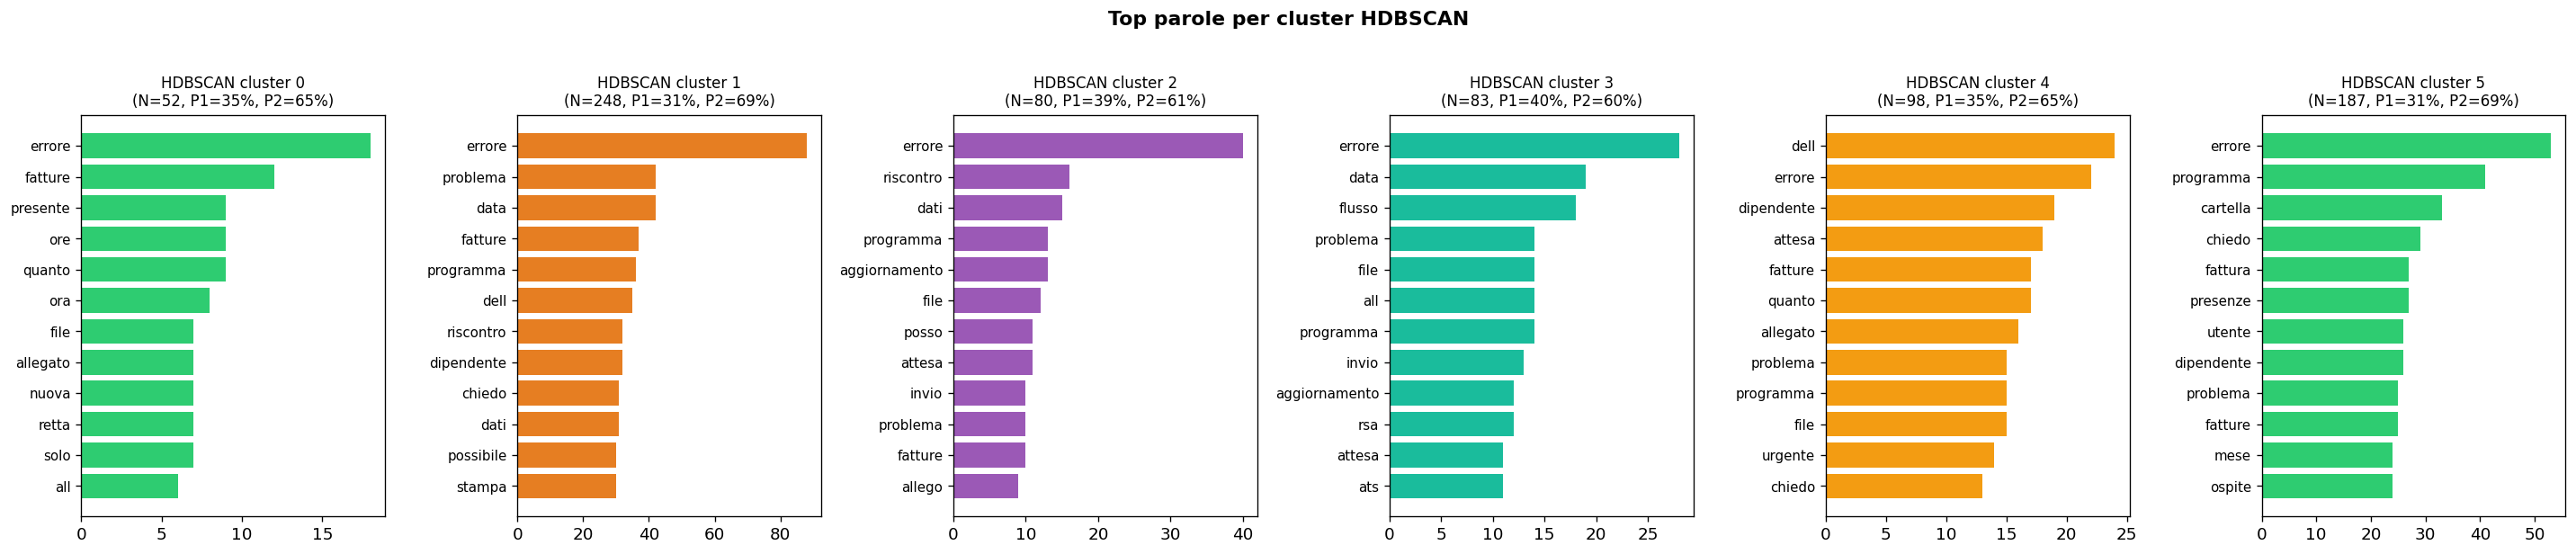

In [ ]:
# ---- Visualizzazione top parole (barh per ogni cluster HDBSCAN) ----
unique_clusters_hdb = sorted([c for c in set(hdb_labels) if c >= 0])
n_cls = len(unique_clusters_hdb)

if n_cls > 0:
    fig, axes = plt.subplots(1, min(n_cls, 6), figsize=(4 * min(n_cls, 6), 5))
    if n_cls == 1:
        axes = [axes]
    for i, cid in enumerate(unique_clusters_hdb[:6]):
        mask = hdb_labels == cid
        texts = df_p1p2_reset.loc[mask, 'testo_input'].fillna('').tolist()
        all_tokens = []
        for t in texts:
            all_tokens.extend(tokenize(t))
        top = Counter(all_tokens).most_common(12)
        words, counts = zip(*top) if top else ([], [])
        p1_pct = (np.array(y)[mask] == 'P1').mean() * 100
        p2_pct = 100 - p1_pct
        axes[i].barh(list(words)[::-1], list(counts)[::-1],
                     color=PALETTE_CLUSTER[i % len(PALETTE_CLUSTER)])
        axes[i].set_title(f'HDBSCAN cluster {cid}\n(N={mask.sum():,}, P1={p1_pct:.0f}%, P2={p2_pct:.0f}%)',
                          fontsize=10)
        axes[i].tick_params(axis='y', labelsize=9)
    plt.suptitle('Top parole per cluster HDBSCAN', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Nessun cluster HDBSCAN trovato (solo noise). Prova a ridurre min_cluster_size.')

## Conclusioni

### Interpretazione dei risultati

- **ARI ≈ 0**: i cluster trovati non corrispondono alle label P1/P2 — lo spazio degli embedding
  non organizza i ticket secondo la priorità operatore.
- **ARI > 0.1**: esiste qualche corrispondenza tra cluster geometrici e label.
- **Silhouette basso (< 0.1)**: i punti sono mescolati, la separazione è debole.
- **Top parole semanticamente coerenti per cluster**: anche se ARI è basso, i cluster
  possono catturare temi (es. area funzionale, tipo problema) distinti dalla priorità.

### Implicazioni per il modello

Se P1 e P2 si sovrappongono nello spazio degli embedding, la frontiera di decisione
del classificatore è necessariamente sottile e dipende da segnali deboli o da feature
non catturate dagli embedding (es. parole chiave specifiche, metadati contestuali).
Questo motiva l'approccio ibrido embedding + keyword features.